In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [3]:
import pandas as pd

df = pd.read_csv('../data/student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
df = df.drop(['G1', 'G2'], axis=1)

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop('G3', axis=1)
y = df['G3']

In [26]:
## Model Training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_lr, rmse_lr

(3.39526092580192, np.float64(4.1956808027213786))

In [12]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [13]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

mae_dt, rmse_dt

(3.6835443037974684, np.float64(4.926035199306855))

In [14]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

mae_rf, rmse_rf

(3.1553164556962026, np.float64(3.9428873632775354))

In [16]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf]
})

results

,Model,MAE,RMSE
0,Linear Regression,3.395261,4.195681
1,Decision Tree,3.683544,4.926035
2,Random Forest,3.155316,3.942887


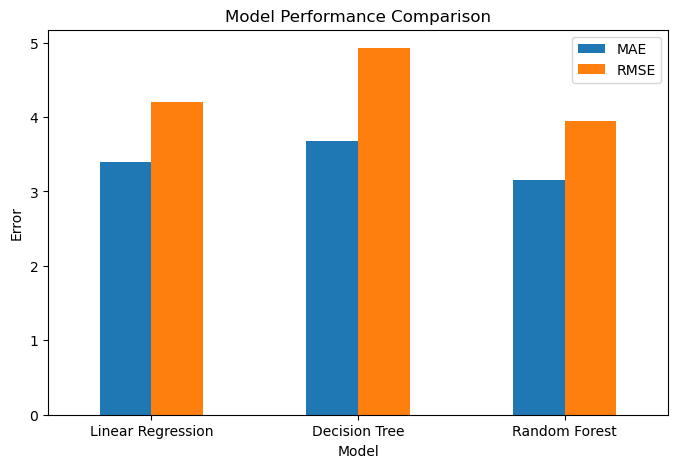

In [24]:
## Model Evaluation
import matplotlib.pyplot as plt

results.plot(x='Model', y=['MAE', 'RMSE'], kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

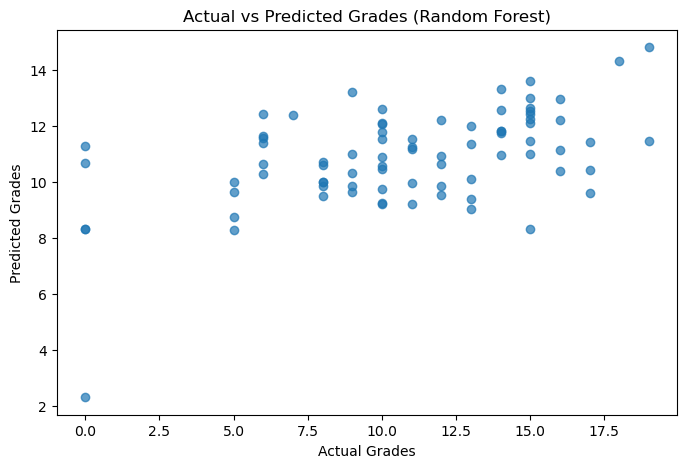

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades (Random Forest)")
plt.show()

In [19]:
"The scatter plot shows that predicted grades follow the actual grades reasonably well, indicating that the model captures important patterns in the data."

'The scatter plot shows that predicted grades follow the actual grades reasonably well, indicating that the model captures important patterns in the data.'

In [20]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
12,absences,0.189961
5,failures,0.143044
11,health,0.054743
8,goout,0.052796
0,age,0.044211
4,studytime,0.034359
7,freetime,0.033035
3,traveltime,0.030748
2,Fedu,0.028491
10,Walc,0.027564


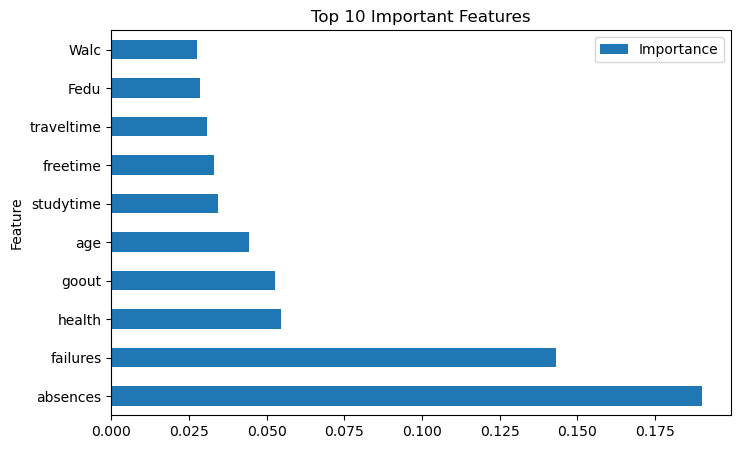

In [21]:
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)
plt.title("Top 10 Important Features")
plt.show()

In [22]:
"The feature importance analysis identified the most influential factors contributing to student performance."

'The feature importance analysis identified the most influential factors contributing to student performance.'